In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                   # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import layers, models
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten       
from tensorflow.keras.callbacks import EarlyStopping    
from tensorflow.keras.utils import to_categorical

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# 데이터 가져오기(32X32 이미지 크기)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# cnn 입력 형태에 맞게 채널 차원을 reshape
y_train = y_train.reshape(-1)     # shape(30000,1) --> (30000)
y_test = y_test.reshape(-1)  # shape(10000,1) --> (10000)


In [9]:
# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
class_names = [
    'airplane',   # 0: 비행기
    'automobile', # 1: 자동차 (승용차)
    'bird',       # 2: 새
    'cat',        # 3: 고양이
    'deer',       # 4: 사슴
    'dog',        # 5: 개
    'frog',       # 6: 개구리
    'horse',      # 7: 말
    'ship',       # 8: 배 (선박)
    'truck'       # 9: 트럭
]

In [11]:
model = models.Sequential([
    
    # 첫 번째 CNN Layer
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)), # 컬러 이미지 입력, 특징 추출
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),                                         # 공간 크기 축소 (다운샘플링)
    layers.Dropout(0.25),                                              # CNN 영역은 0.2~0.3 권장

    # 두 번째 CNN Layer
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # 세 번째 CNN Layer
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    # Fully Connected Layer
    layers.Flatten(),                                                  # 2D -> 1D 벡터로 변환
    layers.Dense(256),                                                 # 256개의 뉴런으로 학습
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),                                               # Dense 영역은 과적합 방지를 위해 0.5 유지

    # 출력층
    layers.Dense(10, activation='softmax')                             # 10개 클래스에 대한 확률 출력
])

model.summary()

D:\anaconda3\envs\youn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 119ms/step - accuracy: 0.4557 - loss: 1.5410 - val_accuracy: 0.4075 - val_loss: 1.7547
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.6015 - loss: 1.1217 - val_accuracy: 0.5953 - val_loss: 1.1367
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 154ms/step - accuracy: 0.6514 - loss: 0.9839 - val_accuracy: 0.6289 - val_loss: 1.0311
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.6852 - loss: 0.8961 - val_accuracy: 0.5056 - val_loss: 1.6221
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.7081 - loss: 0.8328 - val_accuracy: 0.4819 - val_loss: 1.6837
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.7253 - loss: 0.7748 - val_accuracy: 0.4515 - val_loss: 2.0073
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.7417 - loss: 0.7306 - val_accuracy: 0.3667 - val_loss: 2.6139
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.7590 - loss:

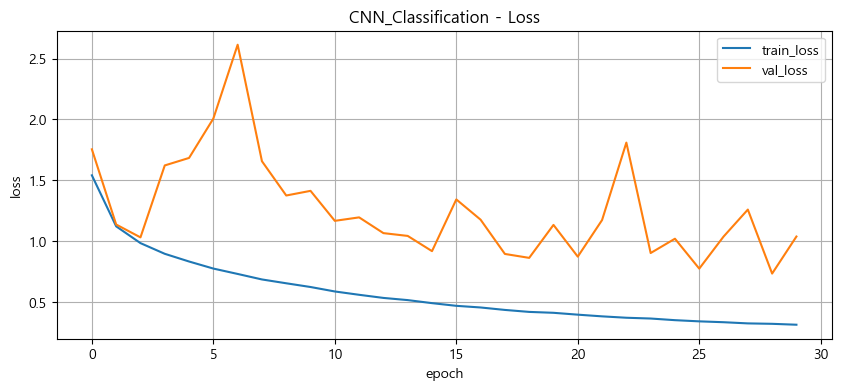

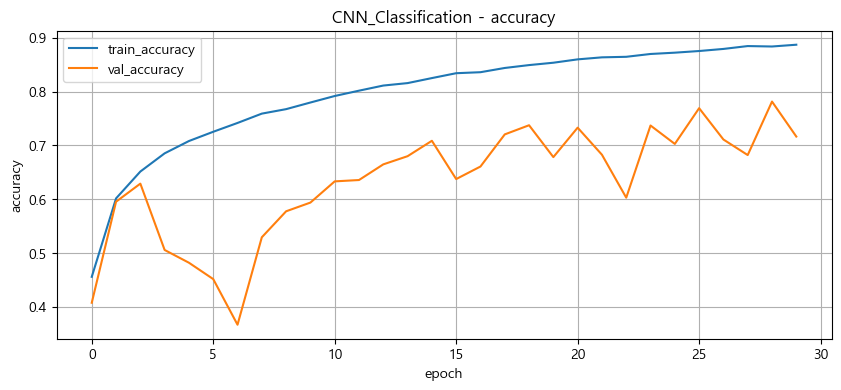

In [15]:
# 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN_Classification - accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


NameError: name 'x_test' is not defined

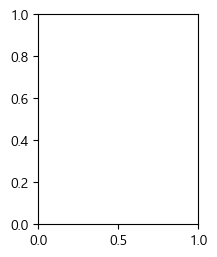

In [20]:
# 10개 이미지 예측 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"정답 : {class_names[y_test[i]]}\n예측 : {class_names[y_pred[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결과", fontsize=16)
plt.show()

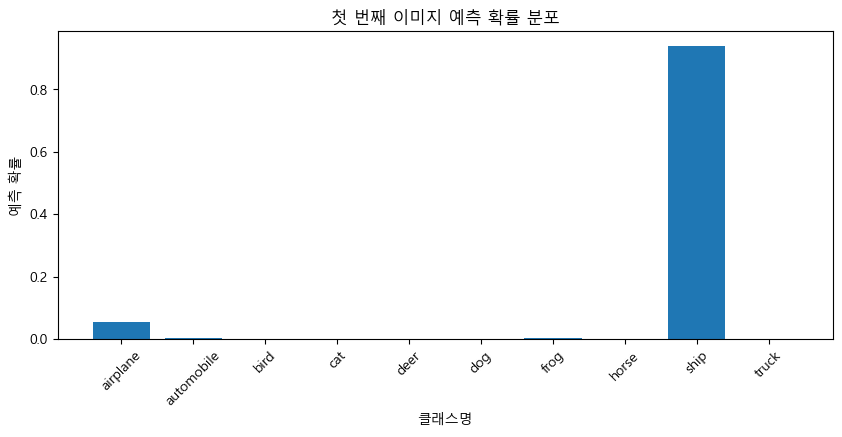

In [18]:
# 개별 이미지 클래스 별 예측 확률 확인
plt.figure(figsize=(10,4))
plt.bar(range(10), y_prob[3])
plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("클래스명")
plt.ylabel("예측 확률")
plt.title("첫 번째 이미지 예측 확률 분포")
plt.show()